In [2]:
import pandas as pd
import matplotlib.pyplot as plt

attrition = pd.read_csv("attrition_log.csv")
employees = pd.read_csv("employees.csv")
engagement = pd.read_csv("engagement.csv")
performance = pd.read_csv("performance.csv")

print("Employees:", employees.shape)
print("Attrition:", attrition.shape)
print("Engagement:", engagement.shape)
print("Performance:", performance.shape)

Employees: (13403, 24)
Attrition: (1400, 10)
Engagement: (55971, 12)
Performance: (34979, 7)


In [11]:
def basic_eda(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "missing": df.isna().sum(),
        "missing_%": df.isna().mean() * 100,
        "unique": df.nunique()
    })

    return summary.sort_values("missing_%", ascending=False)

basic_eda(attrition)

,dtype,missing,missing_%,unique
employee_id,object,0,0.0,1400
exit_date,datetime64[ns],0,0.0,480
exit_type,object,0,0.0,2
stated_exit_reason,object,0,0.0,11
notice_period_served,bool,0,0.0,2
regrettable_flag,bool,0,0.0,2
performance_band_at_exit,object,0,0.0,5
salary_at_exit,float64,0,0.0,832
manager_id_at_exit,object,0,0.0,1196
pathway,object,0,0.0,2


     Exit Type  Count  Percentage
0    voluntary   1133        80.9
1  involuntary    267        19.1


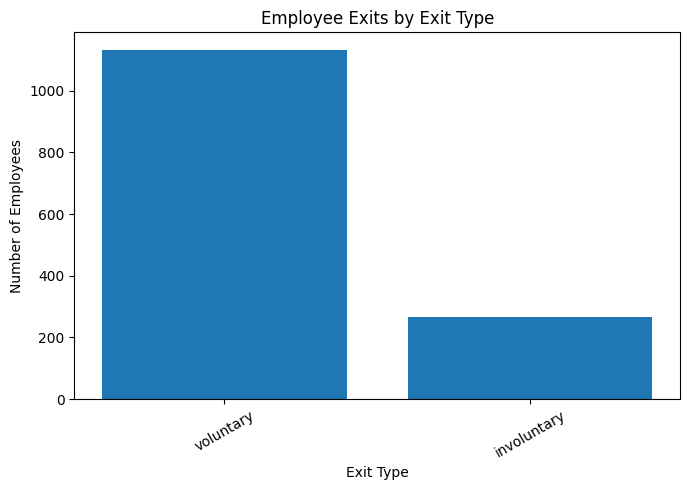

In [13]:
# How many employees exited under each exit type?

exit_summary = (
    attrition["exit_type"]
    .value_counts()
    .rename_axis("Exit Type")
    .reset_index(name="Count")
)

exit_summary["Percentage"] = (
    exit_summary["Count"] /
    exit_summary["Count"].sum() * 100
).round(1)

print(exit_summary)

plt.figure(figsize=(7, 5))

plt.bar(
    exit_summary["Exit Type"],
    exit_summary["Count"]
)

plt.title("Employee Exits by Exit Type")
plt.xlabel("Exit Type")
plt.ylabel("Number of Employees")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


   Regrettable Flag  Count  Percentage
0             False   1247        89.1
1              True    153        10.9


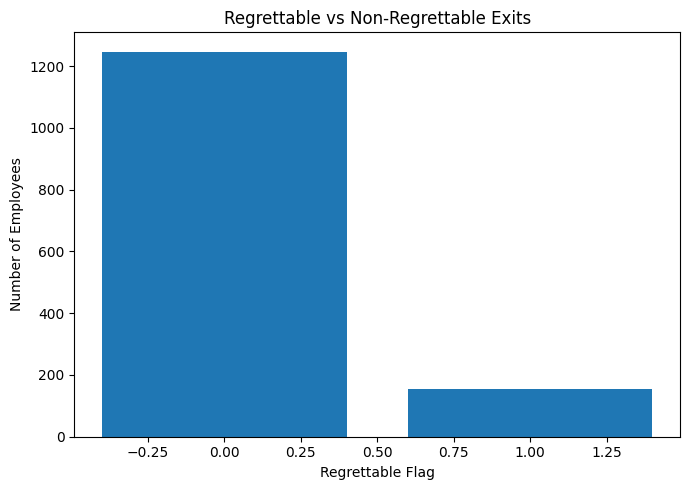

In [12]:
# How many employees exits were regrettable?

regrettable_summary = (
    attrition["regrettable_flag"]
    .value_counts()
    .rename_axis("Regrettable Flag")
    .reset_index(name="Count")
)

regrettable_summary["Percentage"] = (
    regrettable_summary["Count"] /
    regrettable_summary["Count"].sum() * 100
).round(1)

print(regrettable_summary)

plt.figure(figsize=(7, 5))

plt.bar(
    regrettable_summary["Regrettable Flag"],
    regrettable_summary["Count"]
)

plt.title("Regrettable vs Non-Regrettable Exits")
plt.xlabel("Regrettable Flag")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()

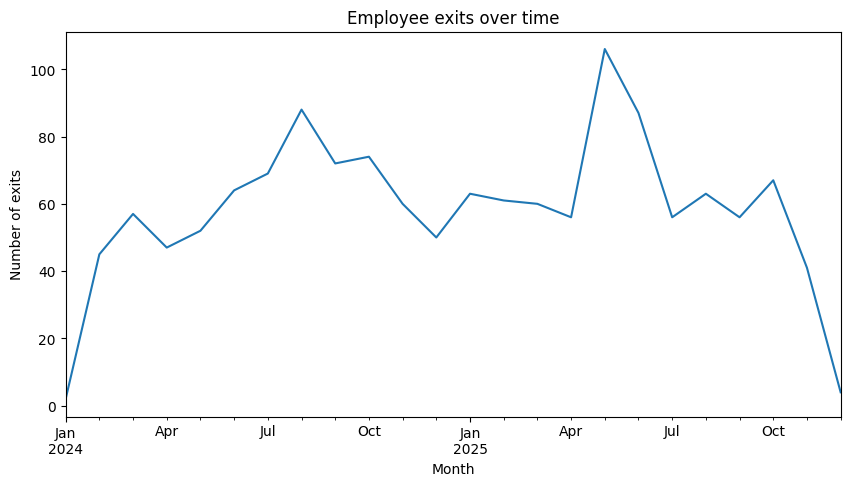

In [9]:
attrition["exit_date"] = pd.to_datetime(
    attrition["exit_date"],
    errors="coerce"
)

attrition["exit_year"] = attrition["exit_date"].dt.year
attrition["exit_month"] = attrition["exit_date"].dt.month
attrition["exit_year"].value_counts().sort_index()

monthly_exits = (
    attrition
    .groupby(attrition["exit_date"].dt.to_period("M"))
    .size()
)

monthly_exits.plot(figsize=(10, 5))

plt.title("Employee exits over time")
plt.xlabel("Month")
plt.ylabel("Number of exits")
plt.show()